In [2]:
from qiskit import __version__

print(__version__)
#!pip install qiskit
#!pip install jupyter
#!pip install sympy
#!pip install matplotlib
#!pip install pylatexenc

2.5.1


In [4]:
import numpy as np

ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

print(ket0 / 2 + ket1 / 2)

M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])
M = M1 / 2 + M2 / 2
print(M)

[[0.5]
 [0.5]]
[[1.  0.5]
 [0.  0.5]]


Matrix multiplication

In [5]:
print(M1 @ ket1)
print(M1 @ M2)
print(M @ M)

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [6]:
from qiskit.visualization import array_to_latex

display(array_to_latex(M1 @ ket1))
display(array_to_latex(M1 @ M2))
display(array_to_latex(M @ M))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

The Statevector class also includes the is_valid method, which checks to see if a given vector is a valid quantum state vector (in other words, that it has Euclidean norm equal to 1):

In [7]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

display(u.draw("text"))
display(u.draw("latex"))
print(u.draw("latex_source"))

display(u.is_valid())
display(w.is_valid())

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


True

False

Η κλάση Statevector περιλαμβάνει επίσης τη μέθοδο is_valid, η οποία ελέγχει αν ένα δεδομένο διάνυσμα είναι έγκυρο διάνυσμα κβαντικής κατάστασης (με άλλα λόγια, αν η Ευκλείδεια νόρμα του είναι ίση με 1)

In [36]:
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

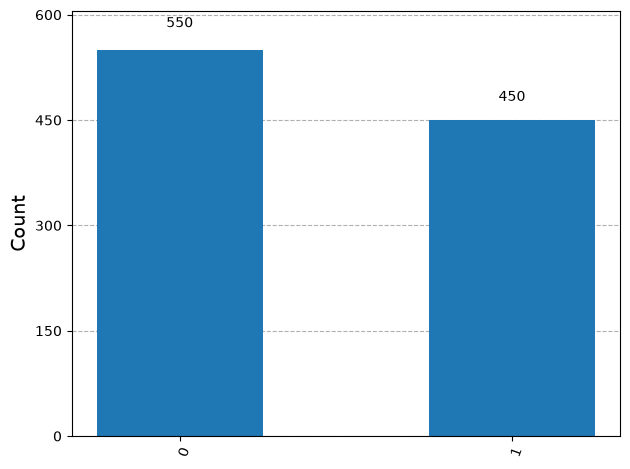

In [41]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

In [42]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

In [43]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

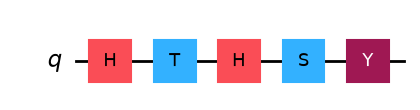

<IPython.core.display.Latex object>

In [ ]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

display(Operator.from_circuit(circuit).draw("latex")) #συνολικό μοναδιαίο πίνακα (unitary operator) που αντιπροσωπεύει ολόκληρο το κύκλωμα

<IPython.core.display.Latex object>

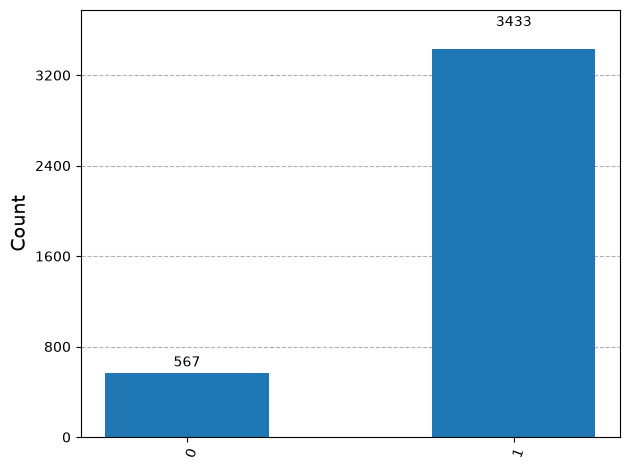

In [54]:
from qiskit.quantum_info import Statevector
f = Statevector(ket0).evolve(circuit) #Επειδή το ket0 ήταν σε μορφή πίνακα,πρέπει να το κάνουμε Statevector
display(f.draw("latex"))

statistics = v.sample_counts(4000)
display(plot_histogram(statistics))

In [ ]:
zero = Statevector.from_label("0")
one = Statevector.from_label("1")
psi = zero.tensor(one)
display(psi.draw("latex"))

In [46]:
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")

phi = plus.tensor(minus_i)
display(phi.draw("latex"))

#display((plus ^ minus_i).draw("latex"))

H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")


display(H.tensor(Id).draw("latex"))
display(H.tensor(Id).tensor(X).draw("latex"))


CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]])
psi = plus.tensor(zero)
display(psi.evolve(CX).draw("latex"))

w = Statevector([0, 1, 1, 0, 1, 0, 0, 0] / np.sqrt(3))
display(w.draw("latex"))

# Μέτρηση μόνο στο Qubit 0 δεξιότερο
result, state = w.measure([0])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

# Μέτρηση στα Qubits 0 και 1 #2 δεξιότερα ψηφία
result, state = w.measure([0, 1])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

# μέτρηση και στα 3 Qubits
result, state = w.measure([0, 1, 2])
print(f"Measured: {result}\nState after measurement:")
display(state.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

Measured: 10
State after measurement:


<IPython.core.display.Latex object>

Measured: 100
State after measurement:


<IPython.core.display.Latex object>